## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional

# Rustworkx for graph operations
import rustworkx as rx
from rustworkx.visualization import mpl_draw

# Qiskit for quantum simulation
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error as depol_error

# ==========================================
# CONFIGURATION: Qubits per Node/Register
# ==========================================
QUBITS_PER_NODE = 3  # Each node holds a register of this many qubits

print(f"Configuration: Each network node has {QUBITS_PER_NODE} qubits")
print("When swapping between nodes, ALL qubits are swapped in parallel (q0↔q0, q1↔q1, ...)")

Configuration: Each network node has 3 qubits
When swapping between nodes, ALL qubits are swapped in parallel (q0↔q0, q1↔q1, ...)


## 2. Define the Network Graph (Multi-Qubit Registers)

We use `rustworkx.PyDiGraph` (directed graph) where:
- **Nodes** are integers representing **register indices** (not individual qubits)
- **Each node has `QUBITS_PER_NODE` qubits** 
- **Edges** connect registers: SWAP ALL qubits in parallel (q0↔q0, q1↔q1, ...)
- **All SWAPs on the same edge share the same error rate**

In [2]:
# ==========================================
# NETWORK TOPOLOGY (Multi-Qubit Registers)
# ==========================================
# Each node represents a REGISTER of QUBITS_PER_NODE qubits
# Edges define SWAP operations between ALL corresponding qubit pairs

graph = rx.PyDiGraph()

# Grid-like lattice topology (same as before, but now each node is a register):
#   SOURCE(0) -- A(1) -- SINK(2)
#       |        |         |
#      E(3)  -- D(4)  -- C(5)

# Node names for display (index = register number)
NODE_NAMES = {0: "SOURCE", 1: "A", 2: "SINK", 3: "E", 4: "D", 5: "C"}

# Add nodes (the integer value IS the register index)
nodes = graph.add_nodes_from([0, 1, 2, 3, 4, 5])

# Define edges with error rates (bidirectional)
# The error rate applies to EACH SWAP gate between corresponding qubits
edge_list = [
    # Top path: SOURCE->A->SINK (Higher error - "direct but noisy")
    (0, 1, 0.06), (1, 0, 0.06),   # SOURCE <-> A
    (1, 2, 0.06), (2, 1, 0.06),   # A <-> SINK
    
    # Bottom path: SOURCE->E->D->C->SINK (Longer but lower error)
    (0, 3, 0.01), (3, 0, 0.01),   # SOURCE <-> E
    (3, 4, 0.01), (4, 3, 0.01),   # E <-> D
    (4, 5, 0.01), (5, 4, 0.01),   # D <-> C
    (5, 2, 0.01), (2, 5, 0.01),   # C <-> SINK
    
    # Cross connections (Medium error)
    (1, 4, 0.04), (4, 1, 0.04),   # A <-> D
]

graph.add_edges_from(edge_list)

# Define Source and Sink
SOURCE_NODE = 0
SINK_NODE = 2

# ==========================================
# HELPER: Convert node index to qubit indices
# ==========================================
def node_to_qubits(node_idx: int) -> List[int]:
    """Convert a node/register index to list of physical qubit indices."""
    start = node_idx * QUBITS_PER_NODE
    return list(range(start, start + QUBITS_PER_NODE))

def get_total_qubits() -> int:
    """Total number of physical qubits in the circuit."""
    return graph.num_nodes() * QUBITS_PER_NODE

print("Quantum Network Created (Multi-Qubit Registers)!")
print("=" * 60)
print(f"Nodes (registers): {graph.num_nodes()}")
print(f"Qubits per register: {QUBITS_PER_NODE}")
print(f"Total physical qubits: {get_total_qubits()}")
print(f"Directed edges: {graph.num_edges()} (bidirectional pairs)")
print(f"Source: register {SOURCE_NODE} ({NODE_NAMES[SOURCE_NODE]})")
print(f"Sink: register {SINK_NODE} ({NODE_NAMES[SINK_NODE]})")
print("\nNode → Qubit mapping:")
for idx in sorted(NODE_NAMES.keys()):
    qubits = node_to_qubits(idx)
    is_special = " [SOURCE]" if idx == SOURCE_NODE else (" [SINK]" if idx == SINK_NODE else "")
    print(f"  {NODE_NAMES[idx]:10} (reg {idx}) → qubits {qubits}{is_special}")

Quantum Network Created (Multi-Qubit Registers)!
Nodes (registers): 6
Qubits per register: 3
Total physical qubits: 18
Directed edges: 14 (bidirectional pairs)
Source: register 0 (SOURCE)
Sink: register 2 (SINK)

Node → Qubit mapping:
  SOURCE     (reg 0) → qubits [0, 1, 2] [SOURCE]
  A          (reg 1) → qubits [3, 4, 5]
  SINK       (reg 2) → qubits [6, 7, 8] [SINK]
  E          (reg 3) → qubits [9, 10, 11]
  D          (reg 4) → qubits [12, 13, 14]
  C          (reg 5) → qubits [15, 16, 17]


In [3]:
# Print edge information (unique edges only)
print("\nEdge Error Rates (SWAP noise per qubit pair):")
print("-" * 60)

printed_edges = set()
for u, v, error_rate in graph.weighted_edge_list():
    edge_key = (min(u, v), max(u, v))
    if edge_key not in printed_edges:
        quality = "Good" if error_rate <= 0.015 else ("Medium" if error_rate <= 0.04 else "High")
        print(f"  {NODE_NAMES[u]:8} ↔ {NODE_NAMES[v]:8}: {error_rate*100:5.1f}% error ({quality})")
        print(f"           Swaps {QUBITS_PER_NODE} qubit pairs: ", end="")
        u_qubits = node_to_qubits(u)
        v_qubits = node_to_qubits(v)
        swap_pairs = [f"q{uq}↔q{vq}" for uq, vq in zip(u_qubits, v_qubits)]
        print(", ".join(swap_pairs))
        printed_edges.add(edge_key)


Edge Error Rates (SWAP noise per qubit pair):
------------------------------------------------------------
  SOURCE   ↔ A       :   6.0% error (High)
           Swaps 3 qubit pairs: q0↔q3, q1↔q4, q2↔q5
  A        ↔ SINK    :   6.0% error (High)
           Swaps 3 qubit pairs: q3↔q6, q4↔q7, q5↔q8
  SOURCE   ↔ E       :   1.0% error (Good)
           Swaps 3 qubit pairs: q0↔q9, q1↔q10, q2↔q11
  E        ↔ D       :   1.0% error (Good)
           Swaps 3 qubit pairs: q9↔q12, q10↔q13, q11↔q14
  D        ↔ C       :   1.0% error (Good)
           Swaps 3 qubit pairs: q12↔q15, q13↔q16, q14↔q17
  C        ↔ SINK    :   1.0% error (Good)
           Swaps 3 qubit pairs: q15↔q6, q16↔q7, q17↔q8
  A        ↔ D       :   4.0% error (Medium)
           Swaps 3 qubit pairs: q3↔q12, q4↔q13, q5↔q14


## 3. Visualize the Network Graph

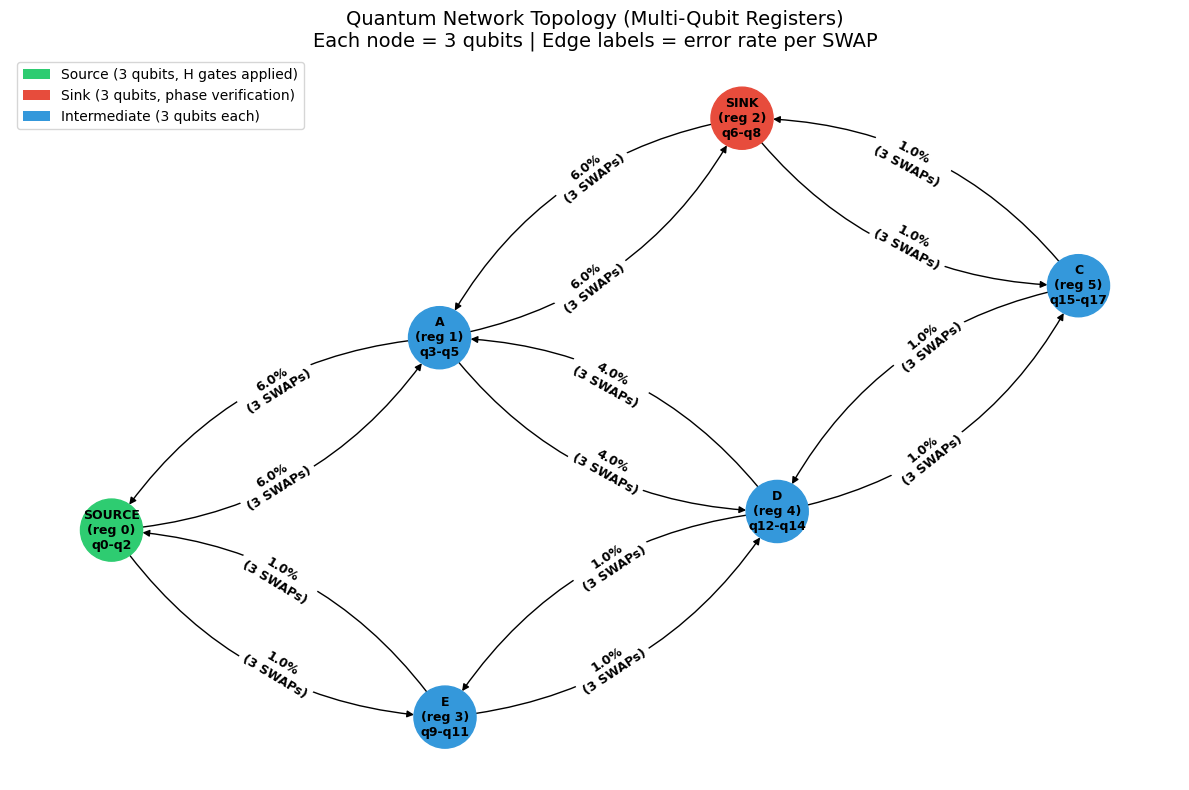

In [4]:
# Visualize the network
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 8))

# Define node colors based on role
node_colors = []
for i in range(graph.num_nodes()):
    if i == SOURCE_NODE:
        node_colors.append('#2ecc71')  # Green for source
    elif i == SINK_NODE:
        node_colors.append('#e74c3c')  # Red for sink
    else:
        node_colors.append('#3498db')  # Blue for others

# Define node labels as function (show register info)
def node_label_fn(node_data):
    qubits = node_to_qubits(node_data)
    return f"{NODE_NAMES[node_data]}\n(reg {node_data})\nq{qubits[0]}-q{qubits[-1]}"

# Define edge labels as function
def edge_label_fn(edge_data):
    return f"{edge_data*100:.1f}%\n({QUBITS_PER_NODE} SWAPs)"

# Draw the directed graph
mpl_draw(graph, 
         ax=ax,
         with_labels=True,
         labels=node_label_fn,
         node_color=node_colors,
         node_size=2000,
         font_size=9,
         font_weight='bold',
         edge_labels=edge_label_fn,
         arrows=True)

ax.set_title(f"Quantum Network Topology (Multi-Qubit Registers)\n"
             f"Each node = {QUBITS_PER_NODE} qubits | Edge labels = error rate per SWAP", fontsize=14)

# Add legend
legend_elements = [
    Patch(facecolor='#2ecc71', label=f'Source ({QUBITS_PER_NODE} qubits, H gates applied)'),
    Patch(facecolor='#e74c3c', label=f'Sink ({QUBITS_PER_NODE} qubits, phase verification)'),
    Patch(facecolor='#3498db', label=f'Intermediate ({QUBITS_PER_NODE} qubits each)'),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

## 3.5 Build Unified Noise Model from Graph

**Key Improvement:** We build ONE noise model for ALL qubit pairs in the network.
- Each edge defines error for `QUBITS_PER_NODE` SWAP operations
- All SWAPs on the same edge share the same error rate

In [5]:
# ==========================================
# BUILD UNIFIED NOISE MODEL FROM GRAPH
# ==========================================
# ONE noise model for ALL qubit pairs across ALL edges

noise_model = NoiseModel()

print(">>> Building Unified Noise Model for Multi-Qubit Registers...")
print("-" * 60)

configured_pairs = set()

for u, v, error_rate in graph.weighted_edge_list():
    # Get the qubit indices for both registers
    u_qubits = node_to_qubits(u)
    v_qubits = node_to_qubits(v)
    
    # Add noise for EACH corresponding qubit pair
    for uq, vq in zip(u_qubits, v_qubits):
        pair = (min(uq, vq), max(uq, vq))
        
        if pair not in configured_pairs:
            # Create a 2-qubit depolarizing error for this SWAP
            err_gate = depol_error(error_rate, 2)
            
            # Attach error to both orderings of this qubit pair
            noise_model.add_quantum_error(err_gate, ['swap'], [uq, vq])
            noise_model.add_quantum_error(err_gate, ['swap'], [vq, uq])
            
            configured_pairs.add(pair)
    
    # Print once per unique edge
    edge_key = (min(u, v), max(u, v))
    if (u, v) == (min(u, v), max(u, v)):  # Only print forward direction
        print(f"  {NODE_NAMES[u]:8} ↔ {NODE_NAMES[v]:8}: {error_rate*100:.1f}% on {QUBITS_PER_NODE} qubit pairs")
        for uq, vq in zip(u_qubits, v_qubits):
            print(f"       q{uq} ↔ q{vq}")

print("-" * 60)
print(f"Noise Model Complete: {len(configured_pairs)} unique qubit pairs configured")
print(f"Total physical qubits: {get_total_qubits()}")

>>> Building Unified Noise Model for Multi-Qubit Registers...
------------------------------------------------------------
  SOURCE   ↔ A       : 6.0% on 3 qubit pairs
       q0 ↔ q3
       q1 ↔ q4
       q2 ↔ q5
  A        ↔ SINK    : 6.0% on 3 qubit pairs
       q3 ↔ q6
       q4 ↔ q7
       q5 ↔ q8
  SOURCE   ↔ E       : 1.0% on 3 qubit pairs
       q0 ↔ q9
       q1 ↔ q10
       q2 ↔ q11
  E        ↔ D       : 1.0% on 3 qubit pairs
       q9 ↔ q12
       q10 ↔ q13
       q11 ↔ q14
  D        ↔ C       : 1.0% on 3 qubit pairs
       q12 ↔ q15
       q13 ↔ q16
       q14 ↔ q17
  SINK     ↔ C       : 1.0% on 3 qubit pairs
       q6 ↔ q15
       q7 ↔ q16
       q8 ↔ q17
  A        ↔ D       : 4.0% on 3 qubit pairs
       q3 ↔ q12
       q4 ↔ q13
       q5 ↔ q14
------------------------------------------------------------
Noise Model Complete: 21 unique qubit pairs configured
Total physical qubits: 18


## 4. Find All Paths from Source to Sink

**Improvement:** Using rustworkx's built-in `all_simple_paths()` instead of custom DFS.

In [6]:
# ==========================================
# FIND ALL SIMPLE PATHS (Using rustworkx built-in)
# ==========================================
all_paths = rx.all_simple_paths(graph, SOURCE_NODE, SINK_NODE)

print(f"Found {len(all_paths)} paths from {NODE_NAMES[SOURCE_NODE]} to {NODE_NAMES[SINK_NODE]}:")
print("=" * 70)

for i, path in enumerate(all_paths):
    path_names = [NODE_NAMES[idx] for idx in path]
    num_edge_hops = len(path) - 1
    total_swaps = num_edge_hops * QUBITS_PER_NODE
    print(f"\nPath {i+1}: {' → '.join(path_names)}")
    print(f"         Registers: {list(path)}")
    print(f"         Edge hops: {num_edge_hops}")
    print(f"         Total SWAP gates: {total_swaps} ({num_edge_hops} edges × {QUBITS_PER_NODE} qubits)")

Found 4 paths from SOURCE to SINK:

Path 1: SOURCE → E → D → A → SINK
         Registers: [0, 3, 4, 1, 2]
         Edge hops: 4
         Total SWAP gates: 12 (4 edges × 3 qubits)

Path 2: SOURCE → E → D → C → SINK
         Registers: [0, 3, 4, 5, 2]
         Edge hops: 4
         Total SWAP gates: 12 (4 edges × 3 qubits)

Path 3: SOURCE → A → D → C → SINK
         Registers: [0, 1, 4, 5, 2]
         Edge hops: 4
         Total SWAP gates: 12 (4 edges × 3 qubits)

Path 4: SOURCE → A → SINK
         Registers: [0, 1, 2]
         Edge hops: 2
         Total SWAP gates: 6 (2 edges × 3 qubits)


In [7]:
def get_path_error_info(path: List[int]) -> List[Tuple[int, int, float]]:
    """Get the error rates for each edge along a path."""
    edge_errors = []
    
    for i in range(len(path) - 1):
        from_idx = path[i]
        to_idx = path[i + 1]
        error_rate = graph.get_edge_data(from_idx, to_idx)
        edge_errors.append((from_idx, to_idx, error_rate))
    
    return edge_errors


# Print error rates for each path
print("\nPath Error Analysis (Multi-Qubit Registers):")
print("=" * 80)

for i, path in enumerate(all_paths):
    path_names = [NODE_NAMES[idx] for idx in path]
    edge_errors = get_path_error_info(path)
    
    # Calculate metrics
    # Each edge has QUBITS_PER_NODE independent SWAPs
    # Combined error for one edge ≈ 1 - (1-e)^n for n qubits
    edge_combined_errors = [1 - (1 - e[2])**QUBITS_PER_NODE for e in edge_errors]
    total_combined_error = 1 - np.prod([1 - e for e in edge_combined_errors])
    
    # Per-qubit fidelity (assuming independent errors)
    per_qubit_fidelity = np.prod([1 - e[2] for e in edge_errors])
    
    print(f"\nPath {i+1}: {' → '.join(path_names)}")
    print(f"  Edge errors (per SWAP):")
    for from_idx, to_idx, err in edge_errors:
        edge_err = 1 - (1 - err)**QUBITS_PER_NODE
        print(f"    {NODE_NAMES[from_idx]} → {NODE_NAMES[to_idx]}: {err*100:.1f}% × {QUBITS_PER_NODE} SWAPs → ~{edge_err*100:.1f}% combined")
    print(f"  Per-qubit expected fidelity: {per_qubit_fidelity*100:.1f}%")
    print(f"  Total register error probability: ~{total_combined_error*100:.1f}%")


Path Error Analysis (Multi-Qubit Registers):

Path 1: SOURCE → E → D → A → SINK
  Edge errors (per SWAP):
    SOURCE → E: 1.0% × 3 SWAPs → ~3.0% combined
    E → D: 1.0% × 3 SWAPs → ~3.0% combined
    D → A: 4.0% × 3 SWAPs → ~11.5% combined
    A → SINK: 6.0% × 3 SWAPs → ~16.9% combined
  Per-qubit expected fidelity: 88.4%
  Total register error probability: ~30.8%

Path 2: SOURCE → E → D → C → SINK
  Edge errors (per SWAP):
    SOURCE → E: 1.0% × 3 SWAPs → ~3.0% combined
    E → D: 1.0% × 3 SWAPs → ~3.0% combined
    D → C: 1.0% × 3 SWAPs → ~3.0% combined
    C → SINK: 1.0% × 3 SWAPs → ~3.0% combined
  Per-qubit expected fidelity: 96.1%
  Total register error probability: ~11.4%

Path 3: SOURCE → A → D → C → SINK
  Edge errors (per SWAP):
    SOURCE → A: 6.0% × 3 SWAPs → ~16.9% combined
    A → D: 4.0% × 3 SWAPs → ~11.5% combined
    D → C: 1.0% × 3 SWAPs → ~3.0% combined
    C → SINK: 1.0% × 3 SWAPs → ~3.0% combined
  Per-qubit expected fidelity: 88.4%
  Total register error probabi

## 5. Build Quantum Circuits for Each Path (Multi-Qubit Registers)

### Circuit Design:

1. **Register per node:** Each node has `QUBITS_PER_NODE` qubits
2. **Parallel SWAPs:** When moving between nodes, swap ALL qubit pairs (q0↔q0, q1↔q1, ...)
3. **Source:** Apply H gate to ALL qubits in source register
4. **Sink:** Apply H to ALL qubits before measuring (phase verification)
5. **Measurement:** Measure ALL qubits in both source and sink registers

In [8]:
def build_path_circuit(path: List[int]) -> QuantumCircuit:
    """
    Build a quantum circuit for a path with multi-qubit register swaps.
    
    Each node = QUBITS_PER_NODE qubits
    Each edge = QUBITS_PER_NODE parallel SWAP gates
    
    Args:
        path: List of register indices forming the path
    
    Returns:
        circuit: The quantum circuit
    """
    total_qubits = get_total_qubits()
    
    # Create registers
    qr = QuantumRegister(total_qubits, 'q')
    # Classical register: measure source (QUBITS_PER_NODE) + sink (QUBITS_PER_NODE)
    cr = ClassicalRegister(2 * QUBITS_PER_NODE, 'c')
    
    qc = QuantumCircuit(qr, cr)
    
    # Get source and sink qubit indices
    src_reg = path[0]
    sink_reg = path[-1]
    src_qubits = node_to_qubits(src_reg)
    sink_qubits = node_to_qubits(sink_reg)
    
    # === SOURCE: Apply H gate to ALL qubits in source register ===
    for sq in src_qubits:
        qc.h(qr[sq])
    qc.barrier(label="Init |+⟩^⊗n")
    
    # === SWAP CHAIN: Transport ALL qubits along the path ===
    for i in range(len(path) - 1):
        u_reg = path[i]
        v_reg = path[i + 1]
        
        u_qubits = node_to_qubits(u_reg)
        v_qubits = node_to_qubits(v_reg)
        
        # Parallel SWAPs for all corresponding qubit pairs
        for uq, vq in zip(u_qubits, v_qubits):
            qc.swap(qr[uq], qr[vq])
        
        qc.barrier(label=f"{NODE_NAMES[u_reg]}→{NODE_NAMES[v_reg]}")
    
    # === PHASE VERIFICATION: Apply H to ALL sink qubits ===
    for skq in sink_qubits:
        qc.h(qr[skq])
    qc.barrier(label="Verify phase")
    
    # === MEASUREMENT: Measure source and sink registers ===
    # First QUBITS_PER_NODE classical bits = source measurements
    for i, sq in enumerate(src_qubits):
        qc.measure(qr[sq], cr[i])
    # Next QUBITS_PER_NODE classical bits = sink measurements
    for i, skq in enumerate(sink_qubits):
        qc.measure(qr[skq], cr[QUBITS_PER_NODE + i])
    
    return qc


# Build circuits for all paths
path_circuits = []

print("Building quantum circuits for each path (Multi-Qubit Registers)...")
print("=" * 70)

for i, path in enumerate(all_paths):
    qc = build_path_circuit(path)
    path_circuits.append((path, qc))
    
    path_names = [NODE_NAMES[idx] for idx in path]
    num_edge_hops = len(path) - 1
    total_swaps = num_edge_hops * QUBITS_PER_NODE
    
    print(f"\nPath {i+1}: {' → '.join(path_names)}")
    print(f"  Total qubits in circuit: {qc.num_qubits}")
    print(f"  Classical bits: {qc.num_clbits} ({QUBITS_PER_NODE} source + {QUBITS_PER_NODE} sink)")
    print(f"  SWAP gates: {total_swaps} ({num_edge_hops} edges × {QUBITS_PER_NODE} parallel)")
    print(f"  Circuit depth: {qc.depth()}")

Building quantum circuits for each path (Multi-Qubit Registers)...

Path 1: SOURCE → E → D → A → SINK
  Total qubits in circuit: 18
  Classical bits: 6 (3 source + 3 sink)
  SWAP gates: 12 (4 edges × 3 parallel)
  Circuit depth: 7

Path 2: SOURCE → E → D → C → SINK
  Total qubits in circuit: 18
  Classical bits: 6 (3 source + 3 sink)
  SWAP gates: 12 (4 edges × 3 parallel)
  Circuit depth: 7

Path 3: SOURCE → A → D → C → SINK
  Total qubits in circuit: 18
  Classical bits: 6 (3 source + 3 sink)
  SWAP gates: 12 (4 edges × 3 parallel)
  Circuit depth: 7

Path 4: SOURCE → A → SINK
  Total qubits in circuit: 18
  Classical bits: 6 (3 source + 3 sink)
  SWAP gates: 6 (2 edges × 3 parallel)
  Circuit depth: 5


Example Circuit: Path 1 (SOURCE → E → D → A → SINK)
Note: 3 parallel SWAPs per edge, H gates on ALL source/sink qubits!


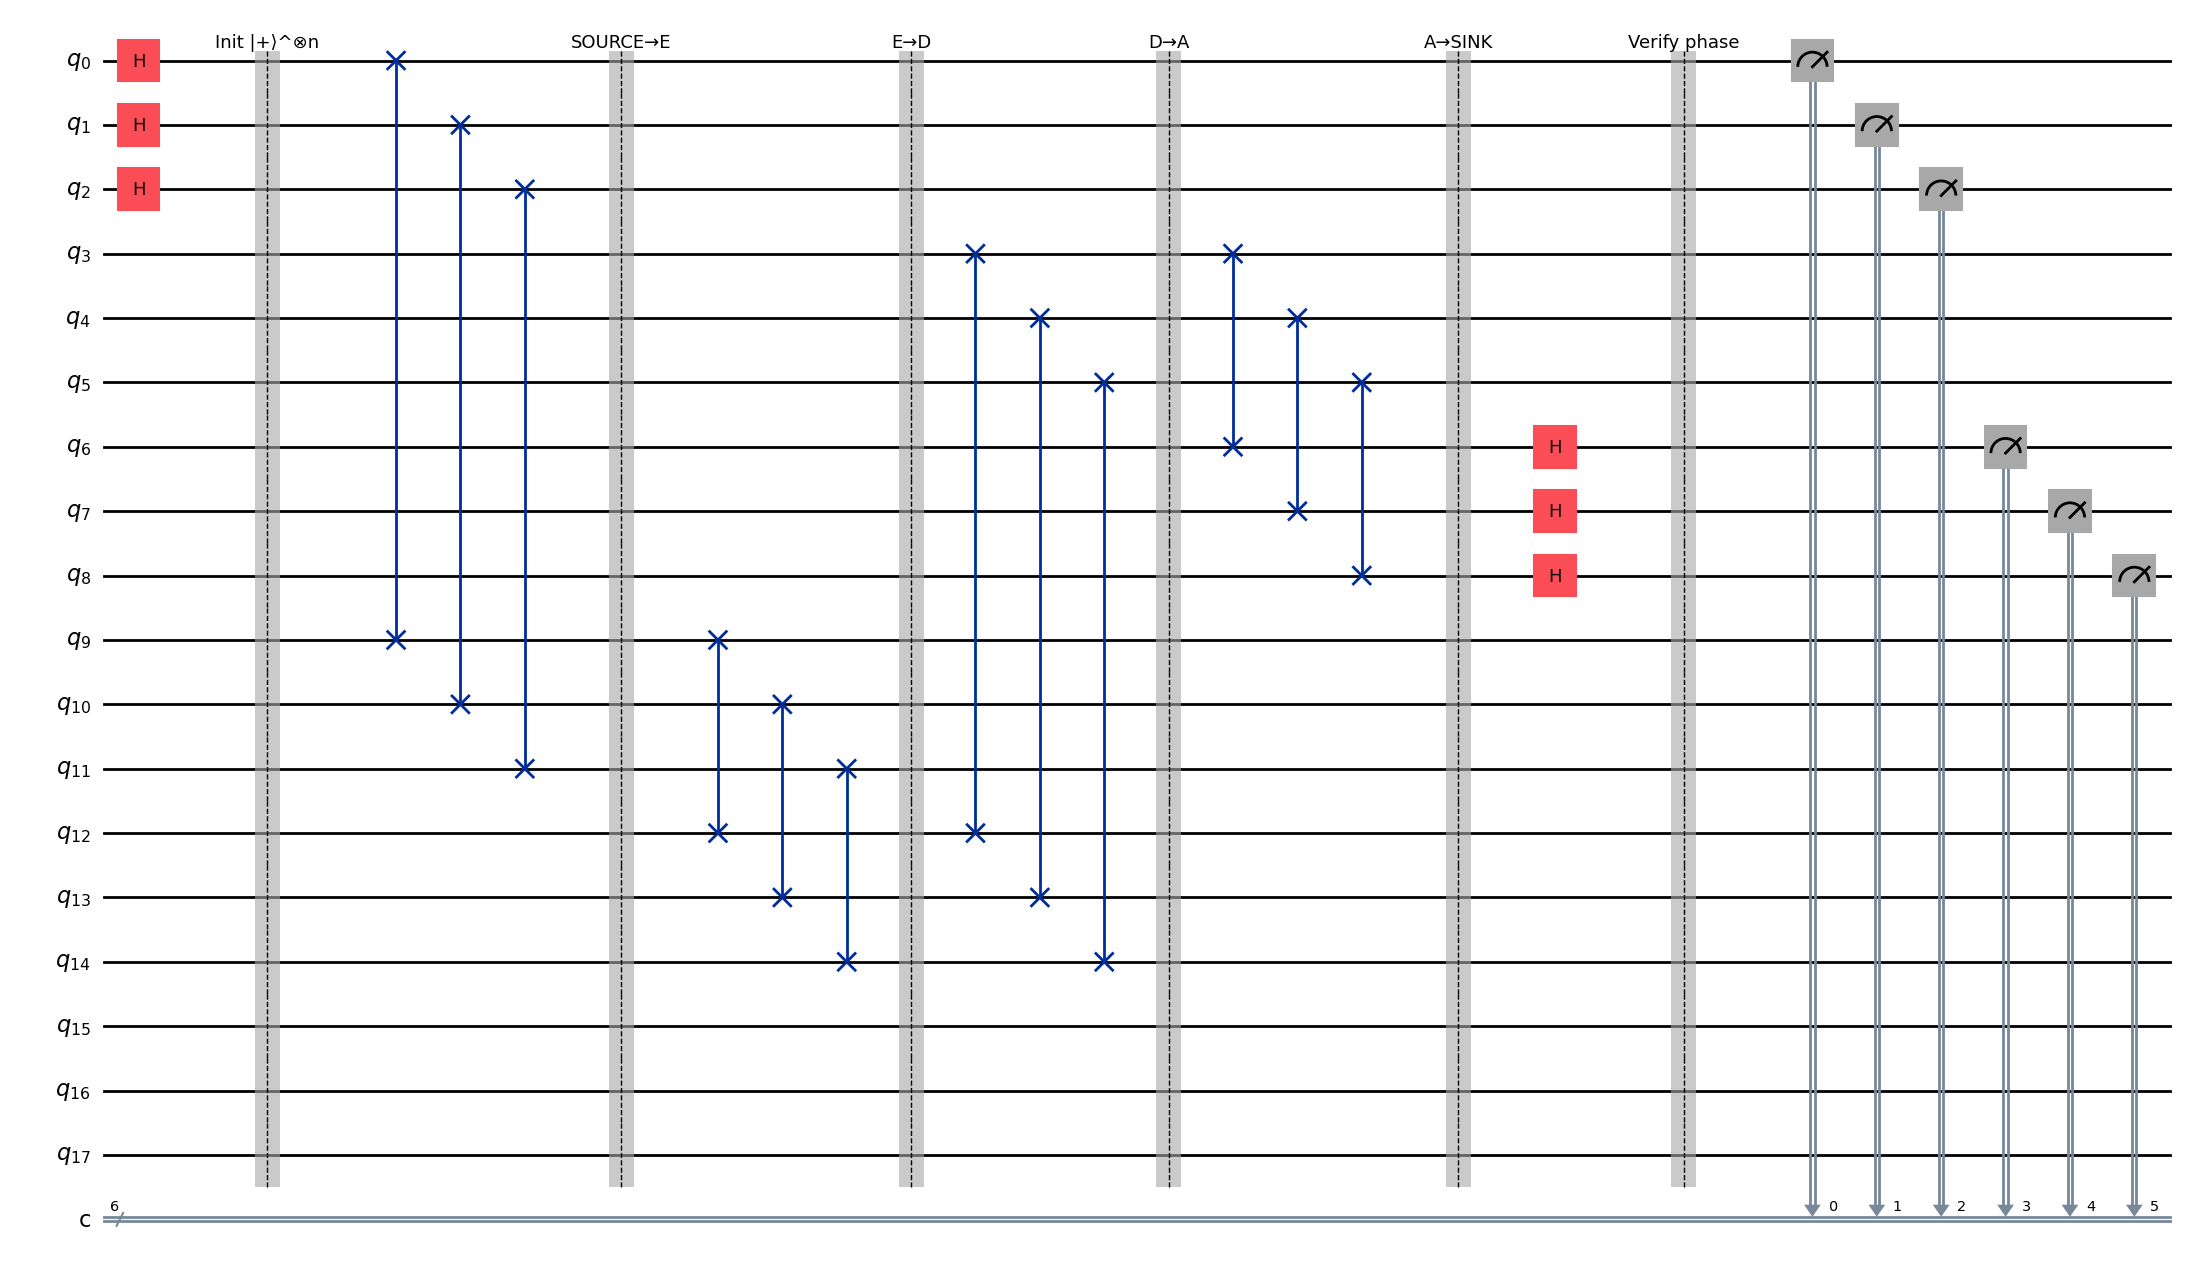

In [9]:
# Visualize one of the circuits
example_path_idx = 0
example_path, example_qc = path_circuits[example_path_idx]

path_names = [NODE_NAMES[idx] for idx in example_path]
print(f"Example Circuit: Path {example_path_idx + 1} ({' → '.join(path_names)})")
print(f"Note: {QUBITS_PER_NODE} parallel SWAPs per edge, H gates on ALL source/sink qubits!")
print("=" * 70)
example_qc.draw(output='mpl', style='iqp', fold=-1)

## 6. Simulate Using Unified Noise Model

**Multi-Qubit Fidelity Metrics:**
- **Per-qubit fidelity:** P(sink qubit i = 0) for each qubit
- **Register fidelity:** P(ALL sink qubits = 0) = joint success probability

In [10]:
def evaluate_path(path: List[int], circuit: QuantumCircuit, shots: int = 2000) -> Tuple[Dict, float, List[float]]:
    """
    Evaluate a path circuit using the unified noise model.
    
    Returns:
        counts: Measurement results
        register_fidelity: P(ALL sink qubits = 0) - full register success
        per_qubit_fidelities: P(sink qubit i = 0) for each qubit
    """
    backend = AerSimulator(noise_model=noise_model)
    transpiled = transpile(circuit, backend, optimization_level=0)
    
    result = backend.run(transpiled, shots=shots).result()
    counts = result.get_counts()
    
    # Calculate fidelities
    # Classical bit ordering: c[0:QUBITS_PER_NODE] = source, c[QUBITS_PER_NODE:] = sink
    # In Qiskit string: rightmost bits are lowest indices
    
    register_success = 0
    per_qubit_success = [0] * QUBITS_PER_NODE
    
    for outcome, count in counts.items():
        outcome = outcome.replace(" ", "")
        
        # Extract sink bits (they are in positions QUBITS_PER_NODE to 2*QUBITS_PER_NODE-1)
        # In the bit string, these are the leftmost QUBITS_PER_NODE bits
        sink_bits = outcome[:QUBITS_PER_NODE]  # Left side = higher indices
        
        # Check if ALL sink bits are 0 (register success)
        if all(b == '0' for b in sink_bits):
            register_success += count
        
        # Count per-qubit successes
        for i, bit in enumerate(reversed(sink_bits)):  # Reverse for correct indexing
            if bit == '0':
                per_qubit_success[i] += count
    
    register_fidelity = register_success / shots
    per_qubit_fidelities = [s / shots for s in per_qubit_success]
    
    return counts, register_fidelity, per_qubit_fidelities


# Run simulations for all paths
results = []
shots = 2000

print(f"Simulating all {len(path_circuits)} paths ({shots} shots each)...")
print("Using UNIFIED noise model (Multi-Qubit Registers)")
print("=" * 80)

for i, (path, qc) in enumerate(path_circuits):
    counts, reg_fidelity, qubit_fidelities = evaluate_path(path, qc, shots)
    edge_info = get_path_error_info(path)
    results.append((path, counts, reg_fidelity, qubit_fidelities, edge_info))
    
    path_names = [NODE_NAMES[idx] for idx in path]
    print(f"\nPath {i+1}: {' → '.join(path_names)}")
    print(f"  Register fidelity (ALL sink qubits = 0): {reg_fidelity*100:.1f}%")
    print(f"  Per-qubit fidelities: {[f'{f*100:.1f}%' for f in qubit_fidelities]}")
    print(f"  Average per-qubit: {np.mean(qubit_fidelities)*100:.1f}%")

Simulating all 4 paths (2000 shots each)...
Using UNIFIED noise model (Multi-Qubit Registers)

Path 1: SOURCE → E → D → A → SINK
  Register fidelity (ALL sink qubits = 0): 83.9%
  Per-qubit fidelities: ['94.8%', '94.0%', '94.2%']
  Average per-qubit: 94.3%

Path 2: SOURCE → E → D → C → SINK
  Register fidelity (ALL sink qubits = 0): 93.7%
  Per-qubit fidelities: ['98.2%', '97.3%', '98.0%']
  Average per-qubit: 97.8%

Path 3: SOURCE → A → D → C → SINK
  Register fidelity (ALL sink qubits = 0): 83.2%
  Per-qubit fidelities: ['93.8%', '94.0%', '94.6%']
  Average per-qubit: 94.1%

Path 4: SOURCE → A → SINK
  Register fidelity (ALL sink qubits = 0): 81.8%
  Per-qubit fidelities: ['93.5%', '94.3%', '92.8%']
  Average per-qubit: 93.5%


## 8. Analyze and Compare Results

In [11]:
# Sort paths by register fidelity (best to worst)
sorted_results = sorted(results, key=lambda x: x[2], reverse=True)

print("\n" + "=" * 90)
print("                    PATH RANKING BY REGISTER FIDELITY")
print("=" * 90)
print(f"\n{'Rank':<6} {'Path':<30} {'Hops':<6} {'SWAPs':<8} {'Reg Fidelity':<14} {'Avg Qubit':<12} {'Status'}")
print("-" * 90)

best_fidelity = sorted_results[0][2]

for rank, (path, counts, reg_fidelity, qubit_fidelities, edge_info) in enumerate(sorted_results, 1):
    path_names = [NODE_NAMES[idx] for idx in path]
    path_str = " → ".join(path_names)
    num_hops = len(path) - 1
    num_swaps = num_hops * QUBITS_PER_NODE
    avg_qubit_fid = np.mean(qubit_fidelities)
    
    status = "★ BEST" if reg_fidelity == best_fidelity else ""
    print(f"{rank:<6} {path_str:<30} {num_hops:<6} {num_swaps:<8} {reg_fidelity*100:<14.1f}% {avg_qubit_fid*100:<12.1f}% {status}")

print("-" * 90)
print(f"\nNote: Register fidelity = P(ALL {QUBITS_PER_NODE} sink qubits = 0)")
print("      This is much stricter than per-qubit fidelity!")


                    PATH RANKING BY REGISTER FIDELITY

Rank   Path                           Hops   SWAPs    Reg Fidelity   Avg Qubit    Status
------------------------------------------------------------------------------------------
1      SOURCE → E → D → C → SINK      4      12       93.7          % 97.8        % ★ BEST
2      SOURCE → E → D → A → SINK      4      12       83.9          % 94.3        % 
3      SOURCE → A → D → C → SINK      4      12       83.2          % 94.1        % 
4      SOURCE → A → SINK              2      6        81.8          % 93.5        % 
------------------------------------------------------------------------------------------

Note: Register fidelity = P(ALL 3 sink qubits = 0)
      This is much stricter than per-qubit fidelity!


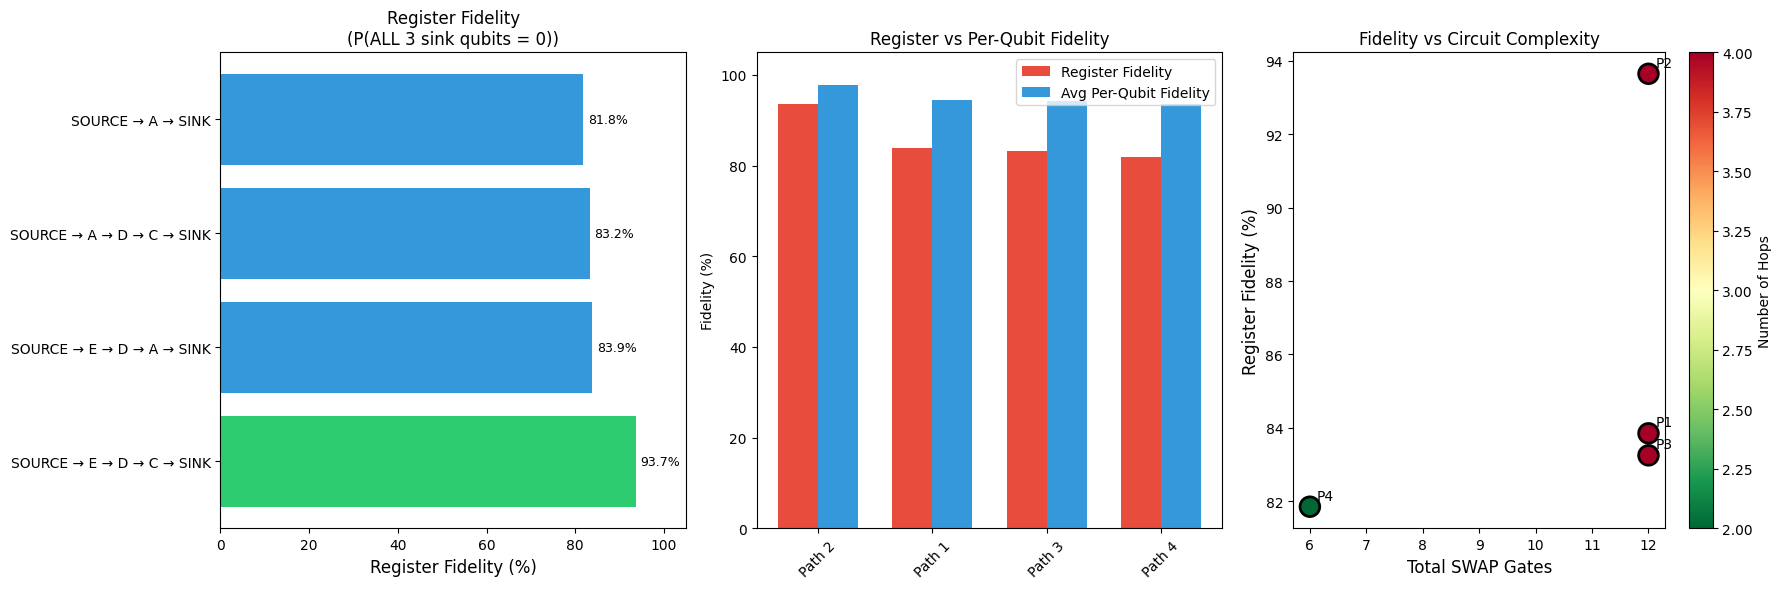

In [12]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Prepare data
path_labels = []
reg_fidelities = []
avg_qubit_fidelities = []
hop_counts = []
total_swaps = []

for path, counts, reg_fidelity, qubit_fidelities, edge_info in results:
    path_names = [NODE_NAMES[idx] for idx in path]
    path_labels.append(" → ".join(path_names))
    reg_fidelities.append(reg_fidelity * 100)
    avg_qubit_fidelities.append(np.mean(qubit_fidelities) * 100)
    hop_counts.append(len(path) - 1)
    total_swaps.append((len(path) - 1) * QUBITS_PER_NODE)

# Sort by register fidelity
sorted_indices = np.argsort(reg_fidelities)[::-1]

# Plot 1: Register Fidelity bar chart
ax1 = axes[0]
colors = ['#2ecc71' if i == sorted_indices[0] else '#3498db' for i in range(len(reg_fidelities))]
bars = ax1.barh(range(len(reg_fidelities)), [reg_fidelities[i] for i in sorted_indices], 
                color=[colors[i] for i in sorted_indices])
ax1.set_yticks(range(len(reg_fidelities)))
ax1.set_yticklabels([path_labels[i] for i in sorted_indices])
ax1.set_xlabel('Register Fidelity (%)', fontsize=12)
ax1.set_title(f'Register Fidelity\n(P(ALL {QUBITS_PER_NODE} sink qubits = 0))', fontsize=12)
ax1.set_xlim(0, 105)
for idx, bar in enumerate(bars):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{reg_fidelities[sorted_indices[idx]]:.1f}%', va='center', fontsize=9)

# Plot 2: Compare Register vs Average Per-Qubit Fidelity
ax2 = axes[1]
x_pos = np.arange(len(path_labels))
width = 0.35
bars1 = ax2.bar(x_pos - width/2, [reg_fidelities[i] for i in sorted_indices], width, 
                label='Register Fidelity', color='#e74c3c')
bars2 = ax2.bar(x_pos + width/2, [avg_qubit_fidelities[i] for i in sorted_indices], width,
                label='Avg Per-Qubit Fidelity', color='#3498db')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'Path {i+1}' for i in sorted_indices], rotation=45)
ax2.set_ylabel('Fidelity (%)')
ax2.set_title('Register vs Per-Qubit Fidelity', fontsize=12)
ax2.legend()
ax2.set_ylim(0, 105)

# Plot 3: Fidelity vs Total SWAPs
ax3 = axes[2]
scatter = ax3.scatter(total_swaps, reg_fidelities, c=hop_counts, cmap='RdYlGn_r', 
                       s=200, edgecolor='black', linewidth=2)
ax3.set_xlabel('Total SWAP Gates', fontsize=12)
ax3.set_ylabel('Register Fidelity (%)', fontsize=12)
ax3.set_title('Fidelity vs Circuit Complexity', fontsize=12)

for i, (x, y) in enumerate(zip(total_swaps, reg_fidelities)):
    short_label = f'P{i+1}'
    ax3.annotate(short_label, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=10)

cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Number of Hops')

plt.tight_layout()
plt.show()

## 9. Detailed Analysis of Best vs Worst Path

In [13]:
# Get best and worst paths
best_result = sorted_results[0]
worst_result = sorted_results[-1]

print("Best vs Worst Path Comparison (Multi-Qubit Registers)")
print("=" * 80)

for label, (path, counts, reg_fidelity, qubit_fidelities, edge_info) in [("BEST", best_result), ("WORST", worst_result)]:
    path_names = [NODE_NAMES[idx] for idx in path]
    num_hops = len(path) - 1
    num_swaps = num_hops * QUBITS_PER_NODE
    
    print(f"\n{label} PATH: {' → '.join(path_names)}")
    print(f"  Register fidelity: {reg_fidelity*100:.1f}%")
    print(f"  Per-qubit fidelities: {[f'{f*100:.1f}%' for f in qubit_fidelities]}")
    print(f"  Number of hops: {num_hops}")
    print(f"  Total SWAP gates: {num_swaps}")
    print(f"  Edge breakdown:")
    
    total_err = 0
    for q1, q2, err in edge_info:
        total_err += err * QUBITS_PER_NODE  # Account for all SWAPs
        print(f"    {NODE_NAMES[q1]} → {NODE_NAMES[q2]}: {err*100:.1f}% × {QUBITS_PER_NODE} SWAPs")
    
    print(f"  Total error budget (all SWAPs): ~{total_err*100:.1f}%")

Best vs Worst Path Comparison (Multi-Qubit Registers)

BEST PATH: SOURCE → E → D → C → SINK
  Register fidelity: 93.7%
  Per-qubit fidelities: ['98.2%', '97.3%', '98.0%']
  Number of hops: 4
  Total SWAP gates: 12
  Edge breakdown:
    SOURCE → E: 1.0% × 3 SWAPs
    E → D: 1.0% × 3 SWAPs
    D → C: 1.0% × 3 SWAPs
    C → SINK: 1.0% × 3 SWAPs
  Total error budget (all SWAPs): ~12.0%

WORST PATH: SOURCE → A → SINK
  Register fidelity: 81.8%
  Per-qubit fidelities: ['93.5%', '94.3%', '92.8%']
  Number of hops: 2
  Total SWAP gates: 6
  Edge breakdown:
    SOURCE → A: 6.0% × 3 SWAPs
    A → SINK: 6.0% × 3 SWAPs
  Total error budget (all SWAPs): ~36.0%


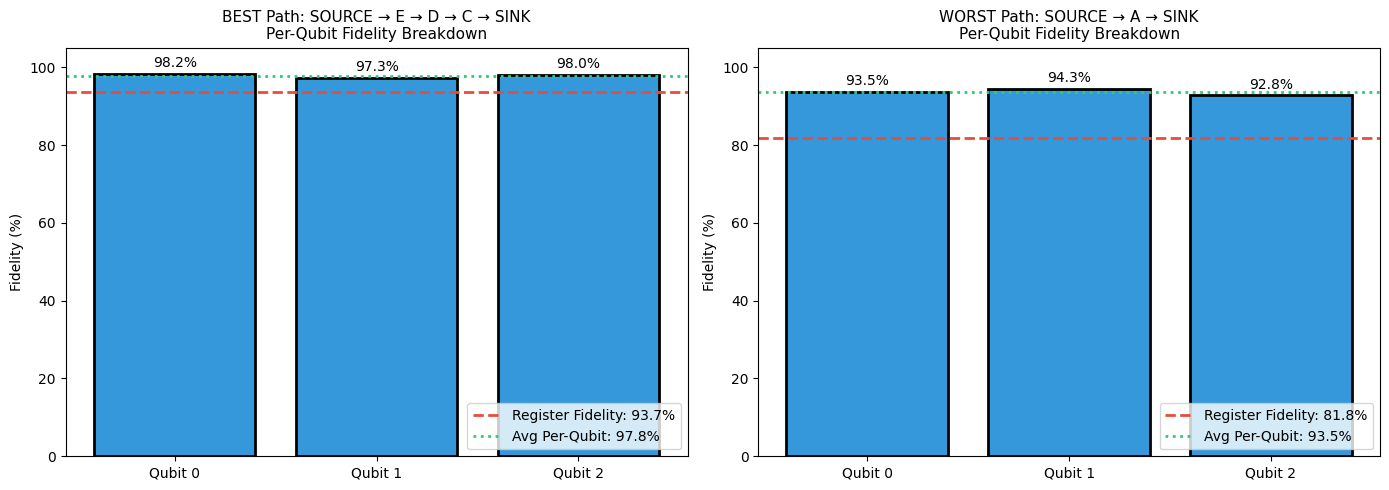

In [14]:
# Per-qubit fidelity comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, (path, counts, reg_fidelity, qubit_fidelities, edge_info)) in zip(axes, [("BEST", best_result), ("WORST", worst_result)]):
    path_names = [NODE_NAMES[idx] for idx in path]
    path_str = " → ".join(path_names)
    
    x_pos = np.arange(QUBITS_PER_NODE)
    bars = ax.bar(x_pos, [f*100 for f in qubit_fidelities], color='#3498db', edgecolor='black', linewidth=2)
    
    ax.axhline(y=reg_fidelity*100, color='#e74c3c', linestyle='--', linewidth=2, 
               label=f'Register Fidelity: {reg_fidelity*100:.1f}%')
    ax.axhline(y=np.mean(qubit_fidelities)*100, color='#2ecc71', linestyle=':', linewidth=2,
               label=f'Avg Per-Qubit: {np.mean(qubit_fidelities)*100:.1f}%')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'Qubit {i}' for i in range(QUBITS_PER_NODE)])
    ax.set_ylabel('Fidelity (%)')
    ax.set_title(f"{label} Path: {path_str}\nPer-Qubit Fidelity Breakdown", fontsize=11)
    ax.set_ylim(0, 105)
    ax.legend(loc='lower right')
    
    # Add value labels
    for bar, fid in zip(bars, qubit_fidelities):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{fid*100:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Verify Qubit Consistency

Let's verify that our constraint is satisfied: the same node always maps to the same qubit across all circuits.

In [15]:
print("Qubit/Register Consistency Verification")
print("=" * 70)
print(f"\nConfiguration: {QUBITS_PER_NODE} qubits per register")
print("\nAll circuits use the same register → qubit mapping:")
print("-" * 50)

for node_idx in sorted(NODE_NAMES.keys()):
    qubits = node_to_qubits(node_idx)
    print(f"  {NODE_NAMES[node_idx]:10} (reg {node_idx}) → qubits {qubits}")

print("\nCircuit sizes (should all be equal):")
print("-" * 50)

for i, (path, qc) in enumerate(path_circuits):
    path_names = [NODE_NAMES[idx] for idx in path]
    print(f"  Path {i+1}: {qc.num_qubits} qubits | {qc.num_clbits} classical bits")

print(f"\n✓ All circuits have {get_total_qubits()} qubits ({graph.num_nodes()} registers × {QUBITS_PER_NODE})")
print(f"✓ Register-to-qubit mapping is consistent across all paths")
print(f"✓ Each edge swaps {QUBITS_PER_NODE} qubit pairs in parallel")

Qubit/Register Consistency Verification

Configuration: 3 qubits per register

All circuits use the same register → qubit mapping:
--------------------------------------------------
  SOURCE     (reg 0) → qubits [0, 1, 2]
  A          (reg 1) → qubits [3, 4, 5]
  SINK       (reg 2) → qubits [6, 7, 8]
  E          (reg 3) → qubits [9, 10, 11]
  D          (reg 4) → qubits [12, 13, 14]
  C          (reg 5) → qubits [15, 16, 17]

Circuit sizes (should all be equal):
--------------------------------------------------
  Path 1: 18 qubits | 6 classical bits
  Path 2: 18 qubits | 6 classical bits
  Path 3: 18 qubits | 6 classical bits
  Path 4: 18 qubits | 6 classical bits

✓ All circuits have 18 qubits (6 registers × 3)
✓ Register-to-qubit mapping is consistent across all paths
✓ Each edge swaps 3 qubit pairs in parallel


## 11. Conclusion

### Summary

In [16]:
# Final summary
best_path, best_counts, best_reg_fidelity, best_qubit_fidelities, best_edge_info = sorted_results[0]
best_path_names = [NODE_NAMES[idx] for idx in best_path]

print("=" * 80)
print("       QUANTUM NETWORK PATHFINDING RESULTS (Multi-Qubit Registers)")
print("=" * 80)
print(f"""
Network Configuration:
  • Nodes (registers): {graph.num_nodes()}
  • Qubits per register: {QUBITS_PER_NODE}
  • Total physical qubits: {get_total_qubits()}
  • Unique edges: {len(set((min(u,v), max(u,v)) for u,v,_ in graph.weighted_edge_list()))}
  • Paths evaluated: {len(all_paths)}

Best Path Found:
  • Route: {' → '.join(best_path_names)}
  • Hops: {len(best_path) - 1}
  • Total SWAP gates: {(len(best_path) - 1) * QUBITS_PER_NODE}
  • Register fidelity: {best_reg_fidelity*100:.1f}%
  • Per-qubit fidelities: {[f'{f*100:.1f}%' for f in best_qubit_fidelities]}
  • Average per-qubit: {np.mean(best_qubit_fidelities)*100:.1f}%

Key Design Features:
  ✓ Multi-qubit registers (not single qubits per node)
  ✓ Parallel SWAPs: q0↔q0, q1↔q1, ... for each edge
  ✓ Same error rate for ALL SWAPs on an edge
  ✓ Unified noise model for consistent physics
  ✓ Two fidelity metrics: register (strict) and per-qubit (lenient)

Insight:
  Register fidelity is MUCH stricter than per-qubit fidelity!
  P(ALL qubits correct) = P(q0)×P(q1)×...×P(qn) ≈ {np.prod(best_qubit_fidelities)*100:.1f}%
  This matches our measured register fidelity: {best_reg_fidelity*100:.1f}%
""")
print("=" * 80)

       QUANTUM NETWORK PATHFINDING RESULTS (Multi-Qubit Registers)

Network Configuration:
  • Nodes (registers): 6
  • Qubits per register: 3
  • Total physical qubits: 18
  • Unique edges: 7
  • Paths evaluated: 4

Best Path Found:
  • Route: SOURCE → E → D → C → SINK
  • Hops: 4
  • Total SWAP gates: 12
  • Register fidelity: 93.7%
  • Per-qubit fidelities: ['98.2%', '97.3%', '98.0%']
  • Average per-qubit: 97.8%

Key Design Features:
  ✓ Multi-qubit registers (not single qubits per node)
  ✓ Parallel SWAPs: q0↔q0, q1↔q1, ... for each edge
  ✓ Same error rate for ALL SWAPs on an edge
  ✓ Unified noise model for consistent physics
  ✓ Two fidelity metrics: register (strict) and per-qubit (lenient)

Insight:
  Register fidelity is MUCH stricter than per-qubit fidelity!
  P(ALL qubits correct) = P(q0)×P(q1)×...×P(qn) ≈ 93.6%
  This matches our measured register fidelity: 93.7%



### Key Features of Multi-Qubit Register Model

1. **Register-Based Nodes**
   - Each network node contains `QUBITS_PER_NODE` qubits
   - State transport moves ALL qubits together
   - Useful for multi-qubit encodings (e.g., error correction codes)

2. **Parallel SWAP Operations**
   - Each edge performs `QUBITS_PER_NODE` parallel SWAPs
   - q0↔q0, q1↔q1, q2↔q2, ... for each hop
   - All SWAPs on the same edge share the same error rate

3. **Fidelity Metrics**
   - **Register Fidelity:** P(ALL sink qubits = 0) - very strict
   - **Per-Qubit Fidelity:** P(qubit i = 0) - more lenient
   - Register fidelity ≈ product of per-qubit fidelities

4. **Scaling Behavior**
   - More qubits per register → lower register fidelity
   - $F_{register} \approx F_{qubit}^n$ where n = qubits per register
   - This models the challenge of transporting multi-qubit states!

### Future Extensions

- **Error correction:** Add redundancy to improve register fidelity
- **Non-uniform registers:** Different nodes could have different sizes
- **Entangled transport:** Transport entangled states across the network
- **Weighted pathfinding:** Account for register size in path selection